<a href="https://colab.research.google.com/github/silentmazz/uluJembutTaqip/blob/PB_AMALI/MUAZ_PBAMALI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MUAZ MUALLIM BIN MOHD TARMIZI,BKV0825KB007,PB AMALI

In [19]:
# Import Library utama PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Import dataset MNIST dan DataLoader
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Import matplotlib untuk menghasilkan graf
import matplotlib.pyplot as plt

print("Library berjaya diimport.")

Library berjaya diimport.


In [20]:
# Menukar imej MNIST kepada tensor
transform = transforms.Compose([
    transforms.ToTensor()
])

# Dataset Latihan
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Dataset Ujian
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Tetapan batch size
batch_size = 64

# DataLoader untuk training
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# DataLoader untuk testing
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Jumlah data latihan:", len(train_dataset))
print("Jumlah data ujian:", len(test_dataset))

Jumlah data latihan: 60000
Jumlah data ujian: 10000


In [21]:
# Membina struktur Artificial Neural Network (ANN)
class ANNModel(nn.Module):
    def __init__(self):
        super(ANNModel, self).__init__()
        # Input Layer (28x28 = 784 piksel) ke Hidden Layer (128 neuron)
        self.hidden = nn.Linear(28 * 28, 128)
        # Fungsi Aktivasi ReLU
        self.relu = nn.ReLU()
        # Hidden Layer ke Output Layer (10 kelas digit 0-9)
        self.output = nn.Linear(128, 10)

    def forward(self, x):
        # Meratakan imej 28x28 kepada vektor 784
        x = x.view(x.size(0), 28 * 28)
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

print("Struktur model ANN berjaya dibina.")

Struktur model ANN berjaya dibina.


In [22]:
# Inisialisasi model sebelum tuning
model_before = ANNModel()

# Fungsi kerugian (Loss Function)
criterion_before = nn.CrossEntropyLoss()

# Learning rate asal sebelum tuning
learning_rate_before = 0.01

# Optimizer Adam
optimizer_before = optim.Adam(model_before.parameters(), lr=learning_rate_before)

print("Learning rate sebelum tuning:", learning_rate_before)

Learning rate sebelum tuning: 0.01


In [23]:
epochs = 5
loss_before = []

# Kitaran latihan model
for epoch in range(epochs):
    model_before.train()
    running_loss = 0.0

    for images, labels in train_loader:
        optimizer_before.zero_grad()            # Reset kecerunan (gradient)
        outputs = model_before(images)          # Forward pass
        loss = criterion_before(outputs, labels) # Kira loss
        loss.backward()                         # Backward pass
        optimizer_before.step()                 # Kemaskini berat (weight update)

        running_loss += loss.item()

    # Purata loss untuk setiap epoch
    epoch_loss = running_loss / len(train_loader)
    loss_before.append(epoch_loss)
    print(f"Epoch {epoch + 1}/{epochs} | Loss: {epoch_loss:.4f}")

Epoch 1/5 | Loss: 0.2243
Epoch 2/5 | Loss: 0.1326
Epoch 3/5 | Loss: 0.1112
Epoch 4/5 | Loss: 0.0989
Epoch 5/5 | Loss: 0.0903


In [24]:
# Pengujian ketepatan model pada dataset ujian
model_before.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model_before(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy_before = 100 * correct / total
print(f"Testing Accuracy Sebelum Tuning: {accuracy_before:.2f}%")

Testing Accuracy Sebelum Tuning: 97.01%


In [25]:
# Cipta model baru untuk eksperimen selepas tuning
model_after = ANN()

# Loss function
criterion_after = nn.CrossEntropyLoss()

# Learning rate selepas tuning
learning_rate_after = 0.001

# Optimizer
optimizer_after = optim.Adam(
    model_after.parameters(),
    lr=learning_rate_after
)

print("Learning rate selepas tuning:", learning_rate_after)

Learning rate selepas tuning: 0.001


In [26]:
# Simpan nilai loss selepas tuning
loss_after = []

for epoch in range(epochs):
    model_after.train()
    total_loss = 0
    for images, labels in train_loader:
        # Reset gradient
        optimizer_after.zero_grad()
        # Forward pass
        outputs = model_after(images)
        # Kira loss
        loss = criterion_after(outputs, labels)
        # Backward pass
        loss.backward()
        # Update weight
        optimizer_after.step()
        total_loss += loss.item()

    # Purata Loss untuk setiap epoch
    average_loss = total_loss / len(train_loader)
    loss_after.append(average_loss)
    print(f"Epoch {epoch + 1}/{epochs} | Loss: {average_loss:.4f}")

Epoch 1/5 | Loss: 0.3420
Epoch 2/5 | Loss: 0.1579
Epoch 3/5 | Loss: 0.1092
Epoch 4/5 | Loss: 0.0835
Epoch 5/5 | Loss: 0.0657


In [27]:
# Tukar model kepada evaluation mode
model_after.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        # Dapatkan output model
        outputs = model_after(images)
        # Pilih kelas dengan nilai tertinggi
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Kira accuracy
accuracy_after = 100 * correct / total
print(f"Testing Accuracy Selepas Tuning: {accuracy_after:.2f}%")

Testing Accuracy Selepas Tuning: 97.66%


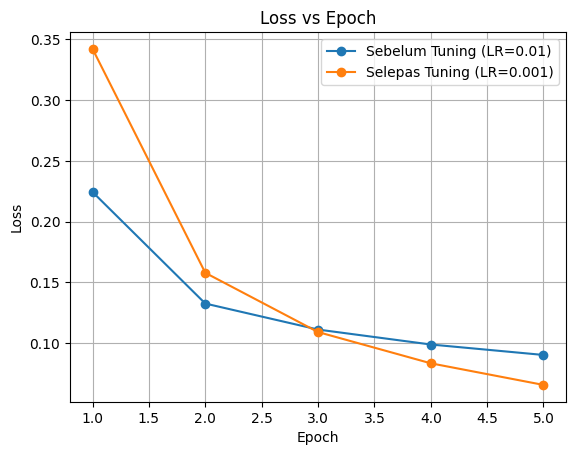

In [28]:
# Nombor epoch untuk paksi X
epoch_numbers = range(1, epochs + 1)

# Plot loss sebelum tuning
plt.plot(
    epoch_numbers,
    loss_before,
    marker="o",
    label="Sebelum Tuning (LR=0.01)"
)

# Plot loss selepas tuning
plt.plot(
    epoch_numbers,
    loss_after,
    marker="o",
    label="Selepas Tuning (LR=0.001)"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
print("=== PERBANDINGAN HASIL ===")
print(f"Sebelum tuning | Learning Rate {learning_rate_before} | Accuracy {accuracy_before:.2f}%")
print(f"Selepas tuning | Learning Rate {learning_rate_after} | Accuracy {accuracy_after:.2f}%")

difference = accuracy_after - accuracy_before

if difference > 0:
    print(f"Accuracy meningkat sebanyak {difference:.2f}% selepas tuning.")
elif difference < 0:
    print(f"Accuracy menurun sebanyak {abs(difference):.2f}% selepas tuning.")
else:
    print("Tiada perubahan pada accuracy.")

=== PERBANDINGAN HASIL ===
Sebelum tuning | Learning Rate 0.01 | Accuracy 97.01%
Selepas tuning | Learning Rate 0.001 | Accuracy 97.66%
Accuracy meningkat sebanyak 0.65% selepas tuning.


In [30]:
# Semak sama ada model mencapai benchmark 80%
if accuracy_after >= 80:
    print(f"Model mencapai benchmark dengan accuracy {accuracy_after:.2f}%.")
else:
    print(f"Accuracy semasa ialah {accuracy_after:.2f}%. Model belum mencapai benchmark 80%.")

Model mencapai benchmark dengan accuracy 97.66%.
